In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir(r'C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit/results')

# Number of random points
n_points = 100_000

# Generate random x,y coordinates between -1 and 1
x = np.random.uniform(-1, 1, n_points)
y = np.random.uniform(-1, 1, n_points)

# Check which points fall inside the unit circle
distances = x**2 + y**2
inside = distances <= 1

# Estimate pi
pi_estimate = 4 * np.sum(inside) / n_points
print(f'Points simulated: {n_points:,}')
print(f'Points inside circle: {np.sum(inside):,}')
print(f'Pi estimate: {pi_estimate:.6f}')
print(f'Actual Pi:   {np.pi:.6f}')
print(f'Error: {abs(pi_estimate - np.pi):.6f}')

Points simulated: 100,000
Points inside circle: 78,650
Pi estimate: 3.146000
Actual Pi:   3.141593
Error: 0.004407


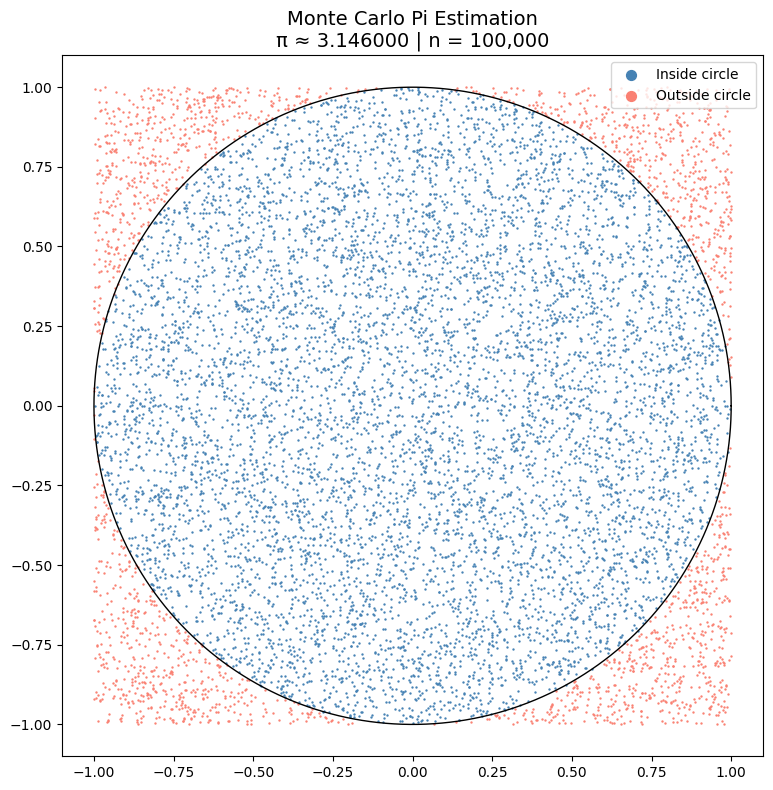

In [2]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot only 10,000 points for clarity
sample = 10_000
ax.scatter(x[:sample][inside[:sample]], y[:sample][inside[:sample]],
           color='steelblue', s=0.5, label='Inside circle')
ax.scatter(x[:sample][~inside[:sample]], y[:sample][~inside[:sample]],
           color='salmon', s=0.5, label='Outside circle')

# Draw the circle
theta = np.linspace(0, 2*np.pi, 1000)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1)

ax.set_aspect('equal')
ax.set_title(f'Monte Carlo Pi Estimation\nπ ≈ {pi_estimate:.6f} | n = {n_points:,}', 
             fontsize=14)
ax.legend(loc='upper right', markerscale=10)
plt.tight_layout()
plt.savefig('../results/01_pi_estimation.png', bbox_inches='tight')
plt.show()

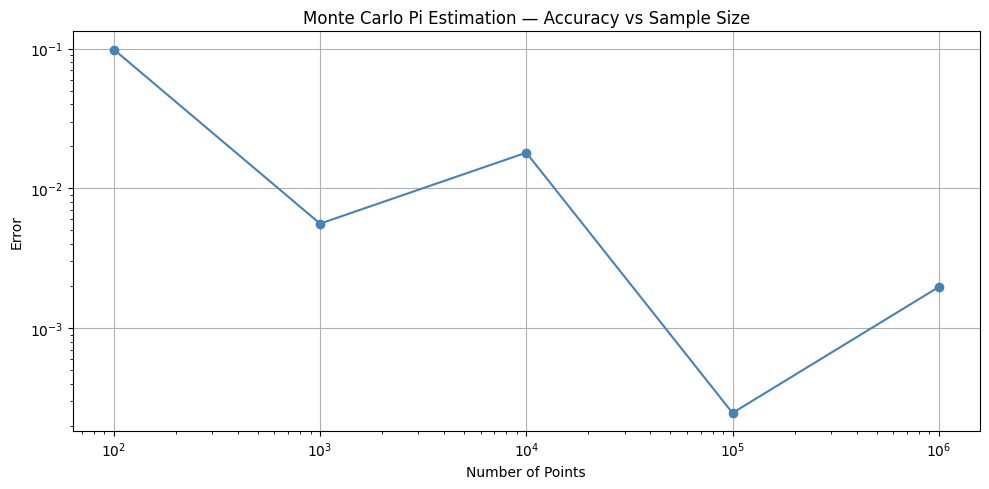

In [3]:
# Show how accuracy improves with more points
sample_sizes = [100, 1_000, 10_000, 100_000, 1_000_000]
errors = []

for n in sample_sizes:
    x = np.random.uniform(-1, 1, n)
    y = np.random.uniform(-1, 1, n)
    inside = (x**2 + y**2) <= 1
    pi_est = 4 * np.sum(inside) / n
    errors.append(abs(pi_est - np.pi))

plt.figure(figsize=(10, 5))
plt.loglog(sample_sizes, errors, 'o-', color='steelblue')
plt.xlabel('Number of Points')
plt.ylabel('Error')
plt.title('Monte Carlo Pi Estimation — Accuracy vs Sample Size')
plt.grid(True)
plt.tight_layout()
plt.savefig('C:/Users/Giannis/.vscode/02_monte_carlo_simulation_toolkit/results/01_pi_convergence.png', bbox_inches='tight')
plt.show()